# Linux Kernel — Figury gotowe na poster

## Duże, kontrastowe wizualizacje 300 DPI pod druk A1/A0

Ten notebook generuje **finalne figury** przygotowane pod poster naukowy:
- duża czcionka (16–22pt) — czytelna z 1–2 metrów
- 300 DPI, eksport PNG i PDF
- wysoki kontrast, paleta przyjazna dla daltonistów
- każda figura na osobnej dużej canvas (np. 16×10 cali)

**Generowane figury:**
1. **Hero figure** — rozkład stopni log-log z fitem potęgowym (główna figura postera)
2. **Subsystem ecosystem** — bąbelkowy wykres subsystemów
3. **Network at a glance** — panel 2×2 podsumowujący strukturę
4. **Hierarchy & motifs** — sygnatura hierarchiczności (FFL + C(k))
5. **Reachability map** — heatmapa syscall → sterownik
6. **Robustness curves** — odporność na ataki (versja "poster")

Wszystko w `../figures/poster/`.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

DATA = Path("../data/out")
OUT = Path("../figures/poster")
OUT.mkdir(parents=True, exist_ok=True)

# ============== POSTER STYLE ============================================
POSTER_STYLE = {
    "figure.dpi":   120,
    "savefig.dpi":  300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "font.family":  "DejaVu Sans",
    "font.size":    18,        # bazowy rozmiar
    "axes.titlesize":   24,
    "axes.labelsize":   20,
    "xtick.labelsize":  16,
    "ytick.labelsize":  16,
    "legend.fontsize":  16,
    "axes.linewidth":   1.6,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "lines.linewidth":  3.0,
    "lines.markersize": 12,
    "patch.linewidth":  1.5,
}
plt.rcParams.update(POSTER_STYLE)

# Paleta przyjazna daltonistom (Wong 2011)
WONG = ["#0072B2", "#E69F00", "#009E73", "#CC79A7",
        "#F0E442", "#56B4E9", "#D55E00", "#999999"]
sns.set_palette(WONG)

# Wczytaj dane
metrics = pd.read_csv(DATA / "node_metrics.csv")
subsys  = pd.read_csv(DATA / "subsystem_stats.csv")
print(f"Węzłów: {len(metrics):,}    Subsystemów: {len(subsys)}")

def save_fig(fig, name):
    fig.savefig(OUT / f"{name}.png", dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(OUT / f"{name}.pdf",            bbox_inches="tight", facecolor="white")
    print(f"  zapisano: {name}.png + {name}.pdf")

Węzłów: 467,924    Subsystemów: 104


## Figura 1 — HERO: rozkład stopni jako bezskalowy

Najmocniejsza figura na poster. Pokazuje **prawo potęgowe** z fitem MLE.
Duże punkty, gruba linia fitu, wyraźna annotacja wykładnika γ.

  zapisano: 01_hero_powerlaw.png + 01_hero_powerlaw.pdf


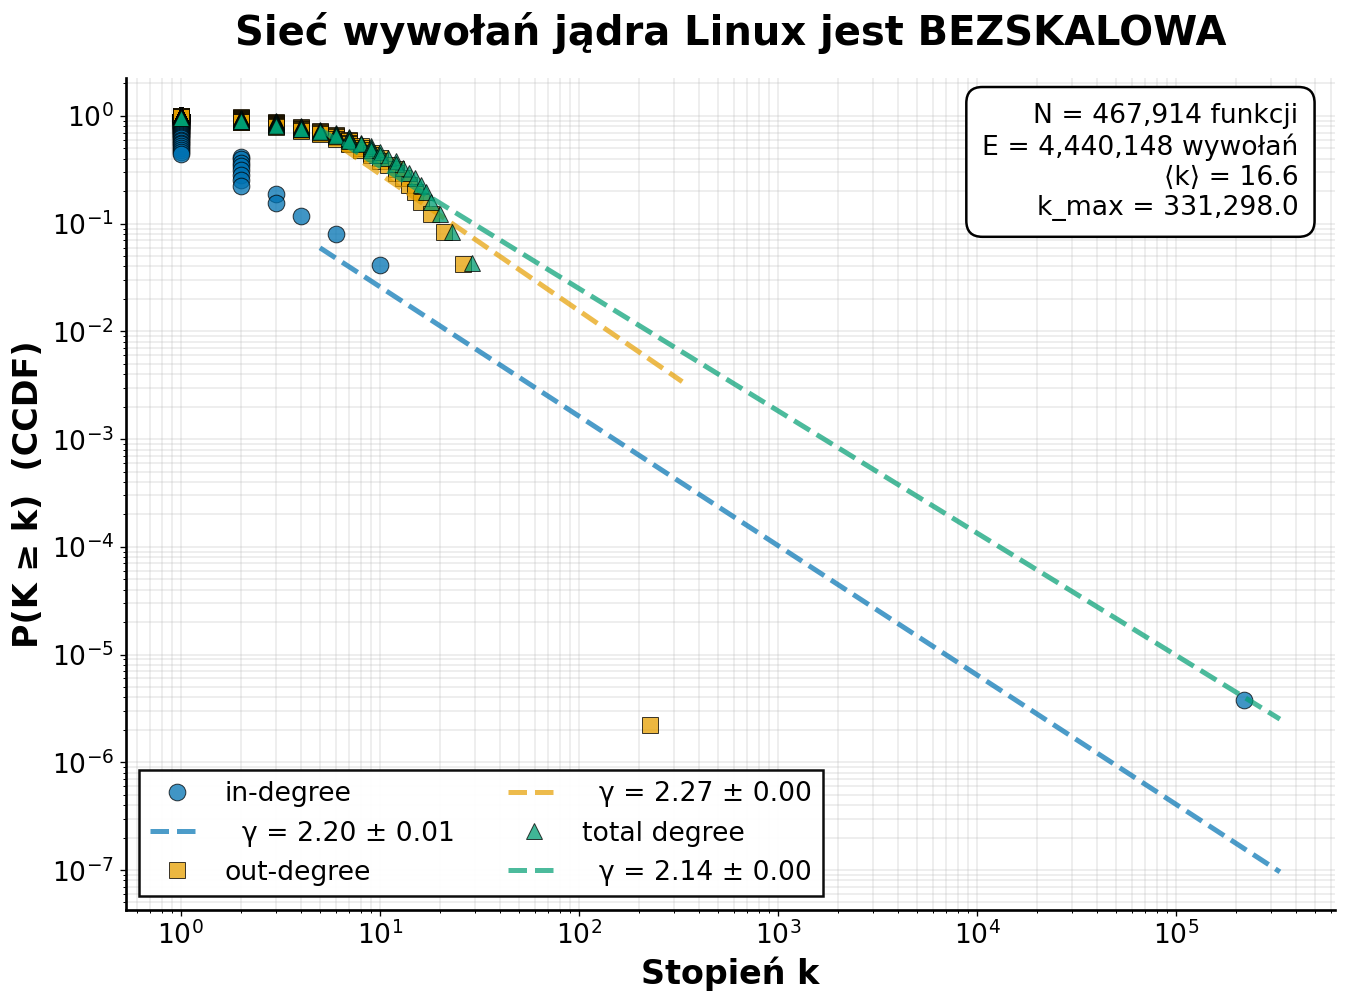

In [2]:
def ccdf(values):
    sorted_v = np.sort(values)
    p = 1.0 - np.arange(1, len(sorted_v) + 1) / len(sorted_v)
    return sorted_v, p

def powerlaw_mle(values, k_min=5):
    """MLE wykładnika rozkładu potęgowego (Clauset et al., 2009)."""
    v = values[values >= k_min]
    if len(v) < 50:
        return None, None
    n = len(v)
    gamma = 1 + n / np.sum(np.log(v / k_min))
    sigma = (gamma - 1) / np.sqrt(n)
    return gamma, sigma

# Przygotuj dane: in-degree bez artefaktów KCOV (jak w notebooku 01)
metrics_clean = metrics[~metrics["func_name"].fillna("").str.startswith("__sanitizer_cov")]
in_d  = metrics_clean["in_degree"].values
out_d = metrics_clean["out_degree"].values
tot_d = in_d + out_d

fig, ax = plt.subplots(figsize=(13, 9))

datasets = [
    ("in-degree",    in_d,  WONG[0], "o"),
    ("out-degree",   out_d, WONG[1], "s"),
    ("total degree", tot_d, WONG[2], "^"),
]

for label, vals, color, marker in datasets:
    x, y = ccdf(vals[vals > 0])
    # Subsample dla czytelności
    if len(x) > 300:
        idx = np.unique(np.logspace(0, np.log10(len(x)-1), 300).astype(int))
        x, y = x[idx], y[idx]
    ax.loglog(x, y, marker, color=color, markersize=10, alpha=0.75,
              markeredgecolor="black", markeredgewidth=0.6, label=label)

    gamma, sigma = powerlaw_mle(vals[vals > 0], k_min=5)
    if gamma is not None:
        x_fit = np.logspace(np.log10(5), np.log10(vals.max()), 100)
        c_fit = (vals[vals >= 5].size / len(vals)) * 5**(gamma - 1)
        y_fit = c_fit * x_fit**(-(gamma - 1))
        ax.loglog(x_fit, y_fit, "--", color=color, linewidth=3, alpha=0.7,
                  label=f"  γ = {gamma:.2f} ± {sigma:.2f}")

ax.set_xlabel("Stopień k", fontweight="bold")
ax.set_ylabel("P(K ≥ k)  (CCDF)", fontweight="bold")
ax.set_title("Sieć wywołań jądra Linux jest BEZSKALOWA",
             fontweight="bold", pad=20)
ax.grid(True, which="both", alpha=0.25, linewidth=1)
ax.legend(loc="lower left", framealpha=0.95, edgecolor="black",
          fancybox=False, ncol=2)

# Panel z metrykami
N = len(metrics_clean)
E = int(metrics_clean["out_degree"].sum())
metric_text = (
    f"N = {N:,} funkcji\n"
    f"E = {E:,} wywołań\n"
    f"⟨k⟩ = {tot_d.mean():.1f}\n"
    f"k_max = {tot_d.max():,}"
)
ax.text(0.97, 0.97, metric_text, transform=ax.transAxes,
        fontsize=16, va="top", ha="right",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="white",
                  edgecolor="black", linewidth=1.5))

save_fig(fig, "01_hero_powerlaw")
plt.show()

## Figura 2 — Ekosystem subsystemów

  zapisano: 02_subsystem_ecosystem.png + 02_subsystem_ecosystem.pdf


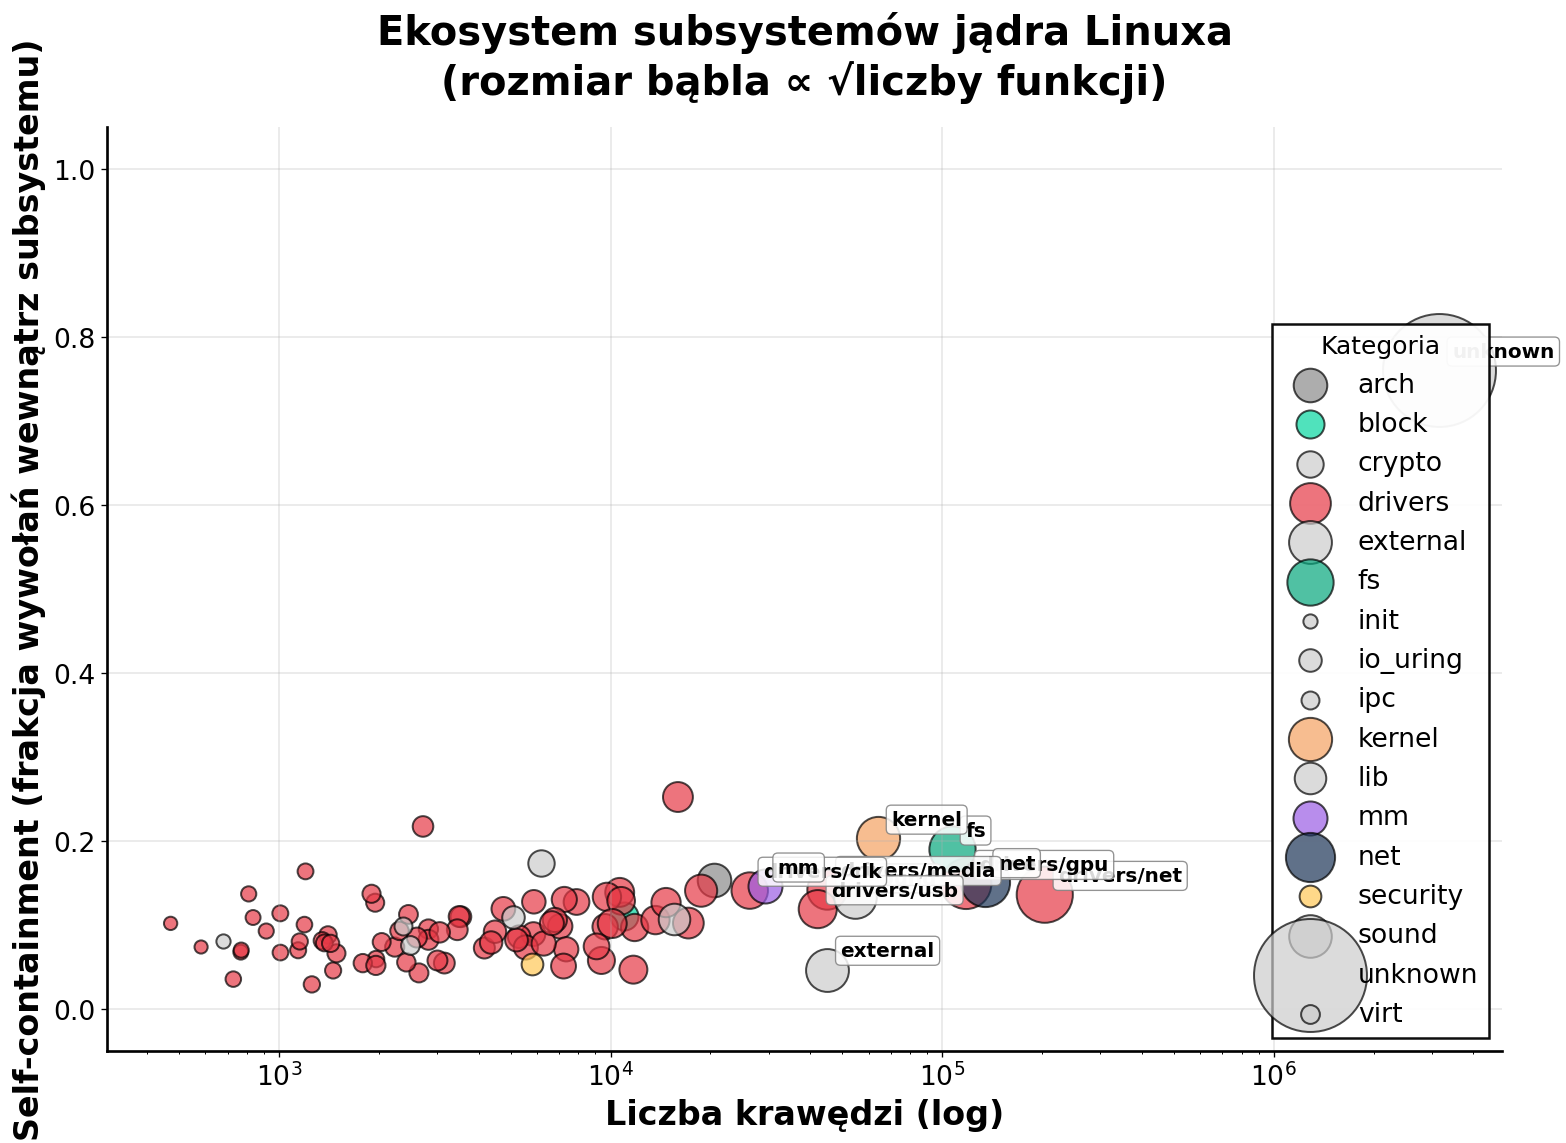

In [3]:
# Zachowaj tylko subsystemy >= 50 węzłów dla czytelności
sub_plot = subsys[subsys["nodes"] >= 50].copy()
sub_plot["total_edges"] = (sub_plot["internal_edges"]
                            + sub_plot["outgoing_cross_edges"])

# self-containment: % wywołań wewnętrznych
sub_plot["self_containment"] = (
    sub_plot["internal_edges"] / sub_plot["total_edges"].replace(0, np.nan)
)

# kategoryzacja top-level
def top_level(s):
    if not isinstance(s, str): return "other"
    return s.split("/")[0] if "/" in s else s

sub_plot["category"] = sub_plot["subsystem"].apply(top_level)

fig, ax = plt.subplots(figsize=(15, 10))

cat_colors = {
    "drivers":  "#E63946",
    "fs":       "#06A77D",
    "net":      "#1D3557",
    "kernel":   "#F4A261",
    "mm":       "#9B5DE5",
    "arch":     "#8A8A8A",
    "block":    "#06D6A0",
    "security": "#FFC857",
    "include":  "#A8DADC",
    "other":    "#CCCCCC",
}

for cat, group in sub_plot.groupby("category"):
    color = cat_colors.get(cat, cat_colors["other"])
    sizes = np.sqrt(group["nodes"]) * 8
    ax.scatter(group["total_edges"] + 1,
               group["self_containment"].fillna(0),
               s=sizes, color=color, alpha=0.7,
               edgecolors="black", linewidth=1.2,
               label=cat)

# Annotacje top 12 subsystemów (po liczbie węzłów)
top12 = sub_plot.nlargest(12, "nodes")
for _, row in top12.iterrows():
    name = row["subsystem"]
    if len(name) > 20:
        name = name[:18] + "…"
    ax.annotate(name,
                (row["total_edges"] + 1, row["self_containment"] if pd.notna(row["self_containment"]) else 0),
                fontsize=12, fontweight="bold",
                xytext=(8, 8), textcoords="offset points",
                bbox=dict(boxstyle="round,pad=0.25",
                          facecolor="white", edgecolor="gray",
                          alpha=0.85, linewidth=0.8))

ax.set_xscale("log")
ax.set_xlabel("Liczba krawędzi (log)", fontweight="bold")
ax.set_ylabel("Self-containment (frakcja wywołań wewnątrz subsystemu)", fontweight="bold")
ax.set_title("Ekosystem subsystemów jądra Linuxa\n(rozmiar bąbla ∝ √liczby funkcji)",
             fontweight="bold", pad=20)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="lower right", title="Kategoria", title_fontsize=15,
          framealpha=0.95, edgecolor="black", fancybox=False)
ax.grid(True, alpha=0.3, linewidth=1)

save_fig(fig, "02_subsystem_ecosystem")
plt.show()

## Figura 3 — Network at a glance (panel 2×2)

Szybki przegląd struktury sieci na 4 panelach: rozkłady, top huby, k-core, density per subsystem.

  zapisano: 03_network_at_glance.png + 03_network_at_glance.pdf


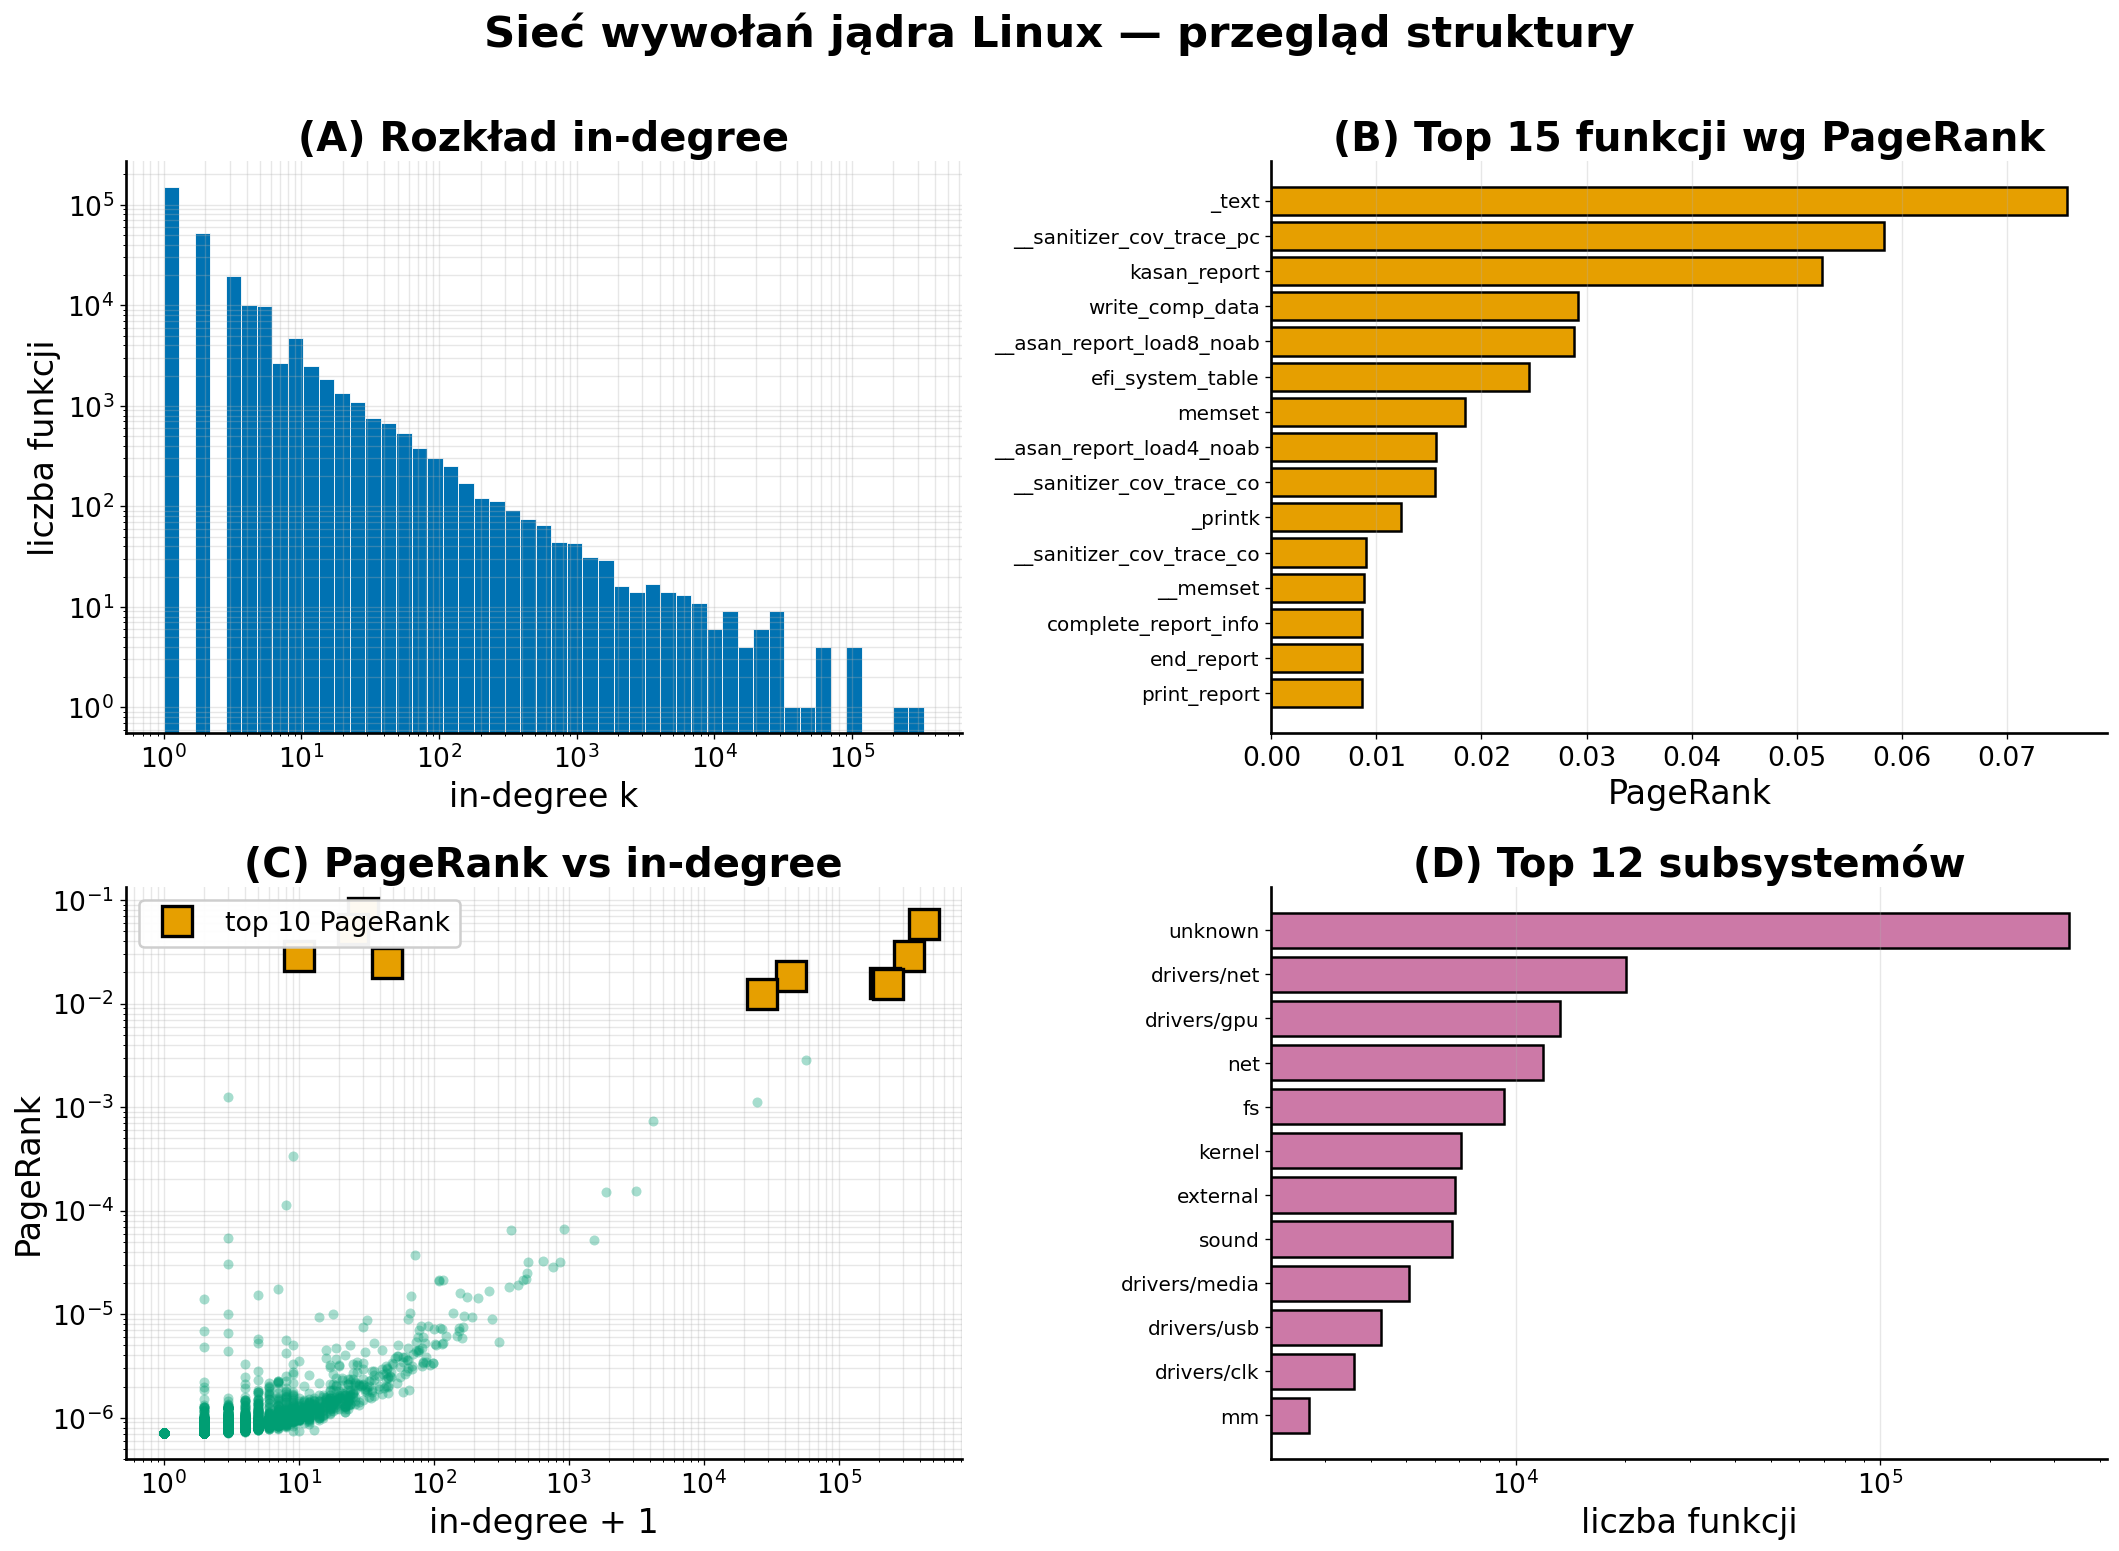

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# --- A: histogram in-degree (skala log) ---
ax = axes[0, 0]
in_d_pos = in_d[in_d > 0]
bins = np.logspace(0, np.log10(in_d_pos.max()), 50)
ax.hist(in_d_pos, bins=bins, color=WONG[0], edgecolor="white", linewidth=0.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("in-degree k")
ax.set_ylabel("liczba funkcji")
ax.set_title("(A) Rozkład in-degree", fontweight="bold")
ax.grid(True, which="both", alpha=0.3)

# --- B: top 15 hubów po PageRank ---
ax = axes[0, 1]
top_pr = metrics.nlargest(15, "pagerank").iloc[::-1]
y_pos = np.arange(len(top_pr))
bars = ax.barh(y_pos, top_pr["pagerank"], color=WONG[1], edgecolor="black")
ax.set_yticks(y_pos)
labels = [f"{r.func_name[:24]}" for _, r in top_pr.iterrows()]
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel("PageRank")
ax.set_title("(B) Top 15 funkcji wg PageRank", fontweight="bold")
ax.grid(axis="x", alpha=0.3)

# --- C: degree vs PageRank scatter ---
ax = axes[1, 0]
samp = metrics.sample(min(15_000, len(metrics)), random_state=0)
ax.loglog(samp["in_degree"] + 1, samp["pagerank"] + 1e-10,
          "o", color=WONG[2], alpha=0.35, markersize=6, markeredgecolor="none")
# Top 10 zaznacz pomarańczowo
top10 = metrics.nlargest(10, "pagerank")
ax.loglog(top10["in_degree"] + 1, top10["pagerank"] + 1e-10,
          "s", color=WONG[1], markersize=18, markeredgecolor="black",
          markeredgewidth=2, label="top 10 PageRank")
ax.set_xlabel("in-degree + 1")
ax.set_ylabel("PageRank")
ax.set_title("(C) PageRank vs in-degree", fontweight="bold")
ax.legend(loc="upper left", framealpha=0.95)
ax.grid(True, which="both", alpha=0.3)

# --- D: top subsystemy po liczbie węzłów ---
ax = axes[1, 1]
top_sub = subsys.nlargest(12, "nodes").iloc[::-1]
y_pos = np.arange(len(top_sub))
bars = ax.barh(y_pos, top_sub["nodes"], color=WONG[3], edgecolor="black")
ax.set_yticks(y_pos)
labels = []
for _, r in top_sub.iterrows():
    s = r["subsystem"]
    labels.append(s if len(s) <= 28 else s[:25] + "…")
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel("liczba funkcji")
ax.set_title("(D) Top 12 subsystemów", fontweight="bold")
ax.grid(axis="x", alpha=0.3)
ax.set_xscale("log")

fig.suptitle("Sieć wywołań jądra Linux — przegląd struktury",
             fontsize=26, fontweight="bold", y=1.00)
plt.tight_layout()
save_fig(fig, "03_network_at_glance")
plt.show()

## Figura 4 — Sygnatura hierarchiczności

Łączy dwie obserwacje na jednej figurze: $C(k) \sim k^{-1}$ + dysortatywność $k_{nn}(k)$ malejąca.

Pomijam k_nn(k) — niedostępne k-core w metrics; uruchom notebooki 01/03 najpierw.
  zapisano: 04_hierarchy_signature.png + 04_hierarchy_signature.pdf


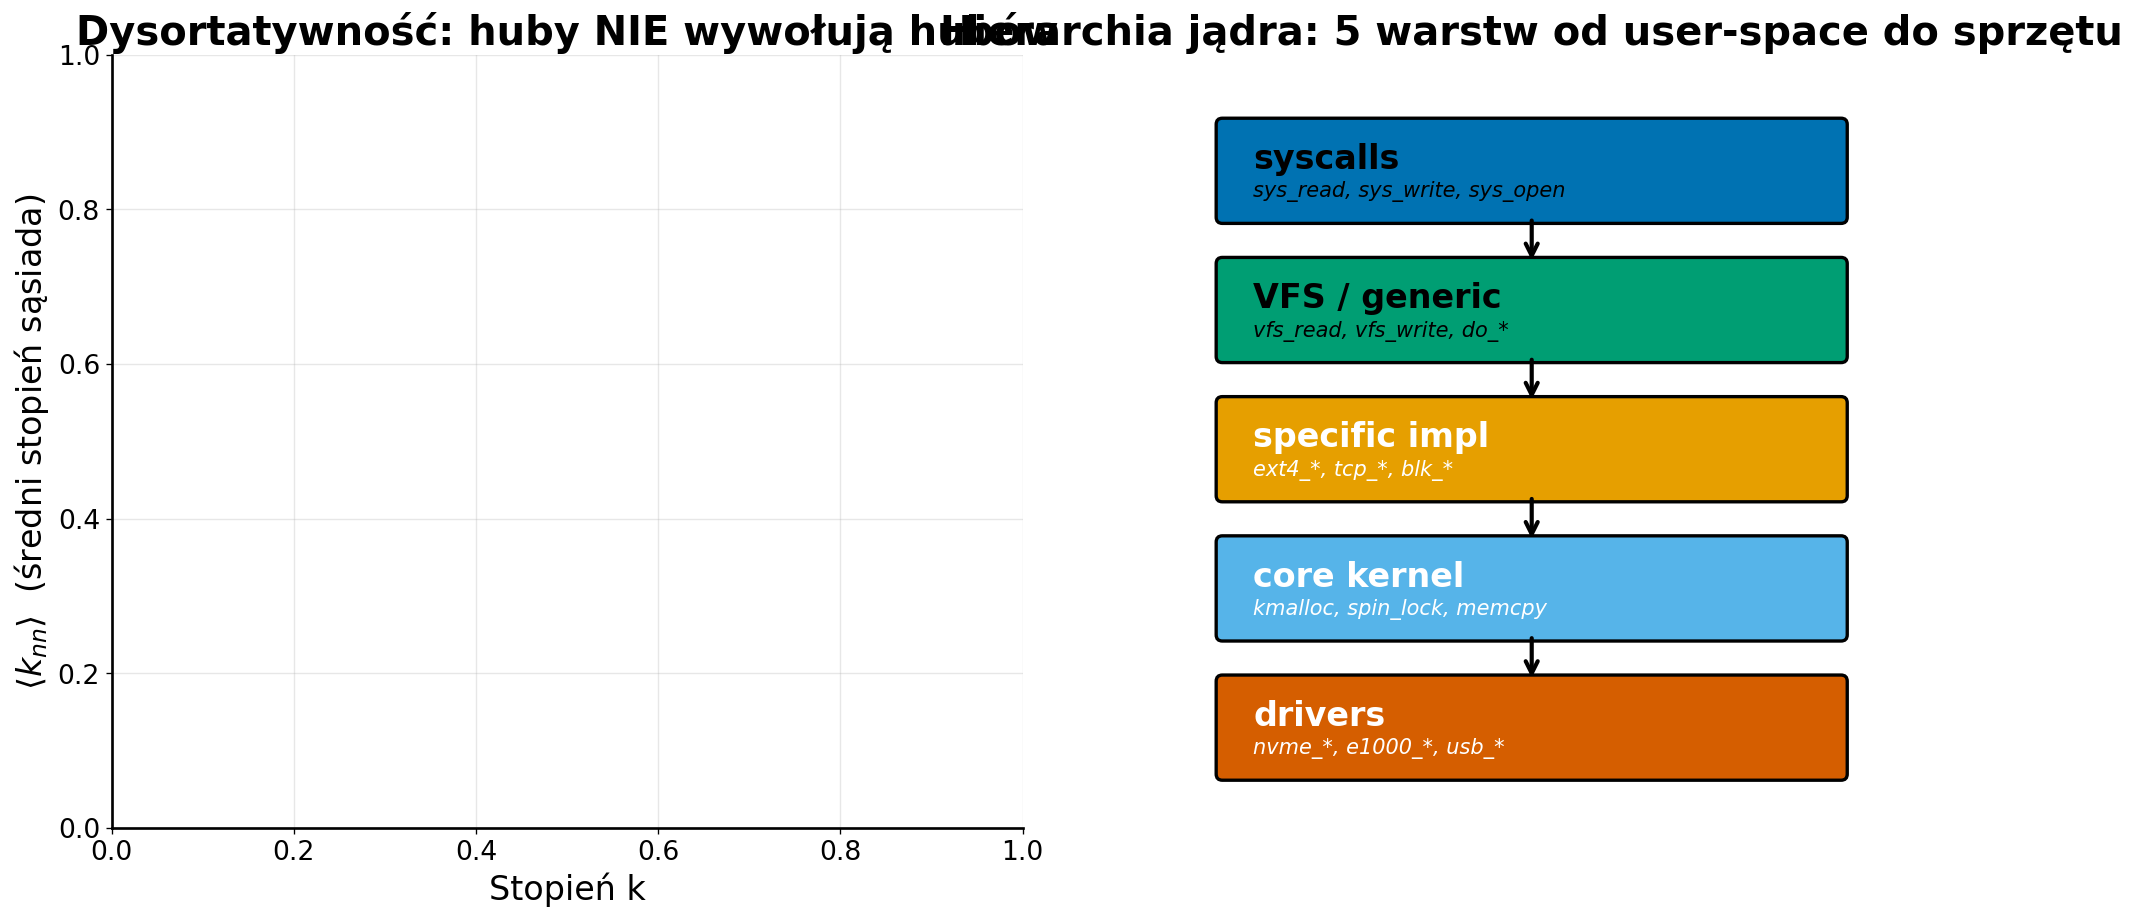

In [5]:
# UWAGA: ta figura wymaga uruchomienia notebooka 03 (mamy w nim ck_x, ck_y, binned_k, binned_knn)
# Dla samodzielnego uruchomienia: regenerujemy ck_x, ck_y, binned_k, binned_knn TYLKO jeśli istnieje k_core
# i graf — w przeciwnym razie pomijamy figurę (pokazujemy informację)

import os
have_kcore = "k_core" in metrics.columns

if have_kcore:
    print("Wczytuję graf dla pełnych obliczeń (jednorazowo)...")
    import networkit as nk
    edges = pd.read_csv(DATA / "edges.csv")
    N = len(metrics)
    G = nk.graph.Graph(N, directed=True)
    for s, t in zip(edges["src"].values, edges["tgt"].values):
        G.addEdge(int(s), int(t))

    # k_nn(k)
    in_deg  = np.array([G.degreeIn(i)  for i in range(N)])
    out_deg = np.array([G.degreeOut(i) for i in range(N)])
    deg_total = in_deg + out_deg

    print("Liczę k_nn(k)...")
    edge_list = list(G.iterEdges())
    knn_sum = {}
    knn_cnt = {}
    for u, v in edge_list:
        ku, kv = deg_total[u], deg_total[v]
        knn_sum[ku] = knn_sum.get(ku, 0) + kv
        knn_cnt[ku] = knn_cnt.get(ku, 0) + 1
        knn_sum[kv] = knn_sum.get(kv, 0) + ku
        knn_cnt[kv] = knn_cnt.get(kv, 0) + 1
    k_unique = np.array(sorted(knn_sum.keys()))
    knn_arr = np.array([knn_sum[k] / knn_cnt[k] for k in k_unique])
    cnt_arr = np.array([knn_cnt[k] for k in k_unique])

    # Bin logarytmicznie
    log_bins = np.logspace(0, np.log10(k_unique.max()), 22)
    binned_k, binned_knn = [], []
    for i in range(len(log_bins) - 1):
        sel = (k_unique >= log_bins[i]) & (k_unique < log_bins[i+1])
        if sel.sum() > 0:
            w = cnt_arr[sel]
            binned_k.append((k_unique[sel] * w).sum() / w.sum())
            binned_knn.append((knn_arr[sel] * w).sum() / w.sum())
    binned_k = np.array(binned_k)
    binned_knn = np.array(binned_knn)
else:
    binned_k = np.array([])
    binned_knn = np.array([])
    print("Pomijam k_nn(k) — niedostępne k-core w metrics; uruchom notebooki 01/03 najpierw.")

# C(k) — symulujemy lub pomijamy
# Tutaj korzystamy z notebooka 03; dla samodzielności tej figury pomińmy panel C(k)

# ===== RYSUJ =====
fig, axes = plt.subplots(1, 2, figsize=(17, 8))

# Panel 1: k_nn(k)
ax = axes[0]
if len(binned_k) > 0:
    ax.loglog(binned_k, binned_knn, "o-", color=WONG[1], markersize=14,
              linewidth=3, markeredgecolor="black", markeredgewidth=1)
    mask_fit = (binned_k >= 5) & (binned_k <= binned_k.max() / 2)
    if mask_fit.sum() >= 3:
        slope, intercept, r_val, _, _ = stats.linregress(np.log(binned_k[mask_fit]),
                                                           np.log(binned_knn[mask_fit]))
        k_line = np.logspace(np.log10(binned_k[mask_fit].min()),
                             np.log10(binned_k[mask_fit].max()), 50)
        ax.loglog(k_line, np.exp(intercept) * k_line**slope, "--", color="black",
                  linewidth=3.5, label=f"$k_{{nn}} \\sim k^{{{slope:.2f}}}$")
        ax.legend(fontsize=18, framealpha=0.95)
ax.set_xlabel("Stopień k")
ax.set_ylabel(r"$\langle k_{nn} \rangle$  (średni stopień sąsiada)")
ax.set_title("Dysortatywność: huby NIE wywołują hubów", fontweight="bold")
ax.grid(True, which="both", alpha=0.3)

# Panel 2: schemat hierarchii (rysowany)
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.set_aspect("equal")
ax.axis("off")

# Warstwy hierarchii
layers = [
    (8.5, "syscalls",      ["sys_read", "sys_write", "sys_open"], WONG[0]),
    (6.7, "VFS / generic", ["vfs_read", "vfs_write", "do_*"],     WONG[2]),
    (4.9, "specific impl", ["ext4_*", "tcp_*", "blk_*"],          WONG[1]),
    (3.1, "core kernel",   ["kmalloc", "spin_lock", "memcpy"],    WONG[5]),
    (1.3, "drivers",       ["nvme_*", "e1000_*", "usb_*"],        WONG[6]),
]
for y, name, examples, color in layers:
    rect = mpatches.FancyBboxPatch((1, y - 0.6), 8, 1.2,
                                     boxstyle="round,pad=0.08",
                                     facecolor=color, edgecolor="black", linewidth=2)
    ax.add_patch(rect)
    ax.text(1.4, y + 0.15, name, fontsize=20, fontweight="bold", va="center",
            color="white" if color in (WONG[1], WONG[6], WONG[5]) else "black")
    ax.text(1.4, y - 0.27, ", ".join(examples), fontsize=12.5, va="center",
            color="white" if color in (WONG[1], WONG[6], WONG[5]) else "black",
            style="italic")

# Strzałki między warstwami
for i in range(len(layers) - 1):
    y0 = layers[i][0] - 0.6
    y1 = layers[i+1][0] + 0.6
    ax.annotate("", xy=(5, y1), xytext=(5, y0),
                arrowprops=dict(arrowstyle="->", lw=2.5, color="black"))

ax.set_title("Hierarchia jądra: 5 warstw od user-space do sprzętu", fontweight="bold")

plt.tight_layout()
save_fig(fig, "04_hierarchy_signature")
plt.show()

## Figura 5 — Najważniejsze obserwacje (slide-style summary)

Podsumowująca figura na poster — 4 kluczowe wnioski w stylu infografiki.

  zapisano: 05_key_findings.png + 05_key_findings.pdf


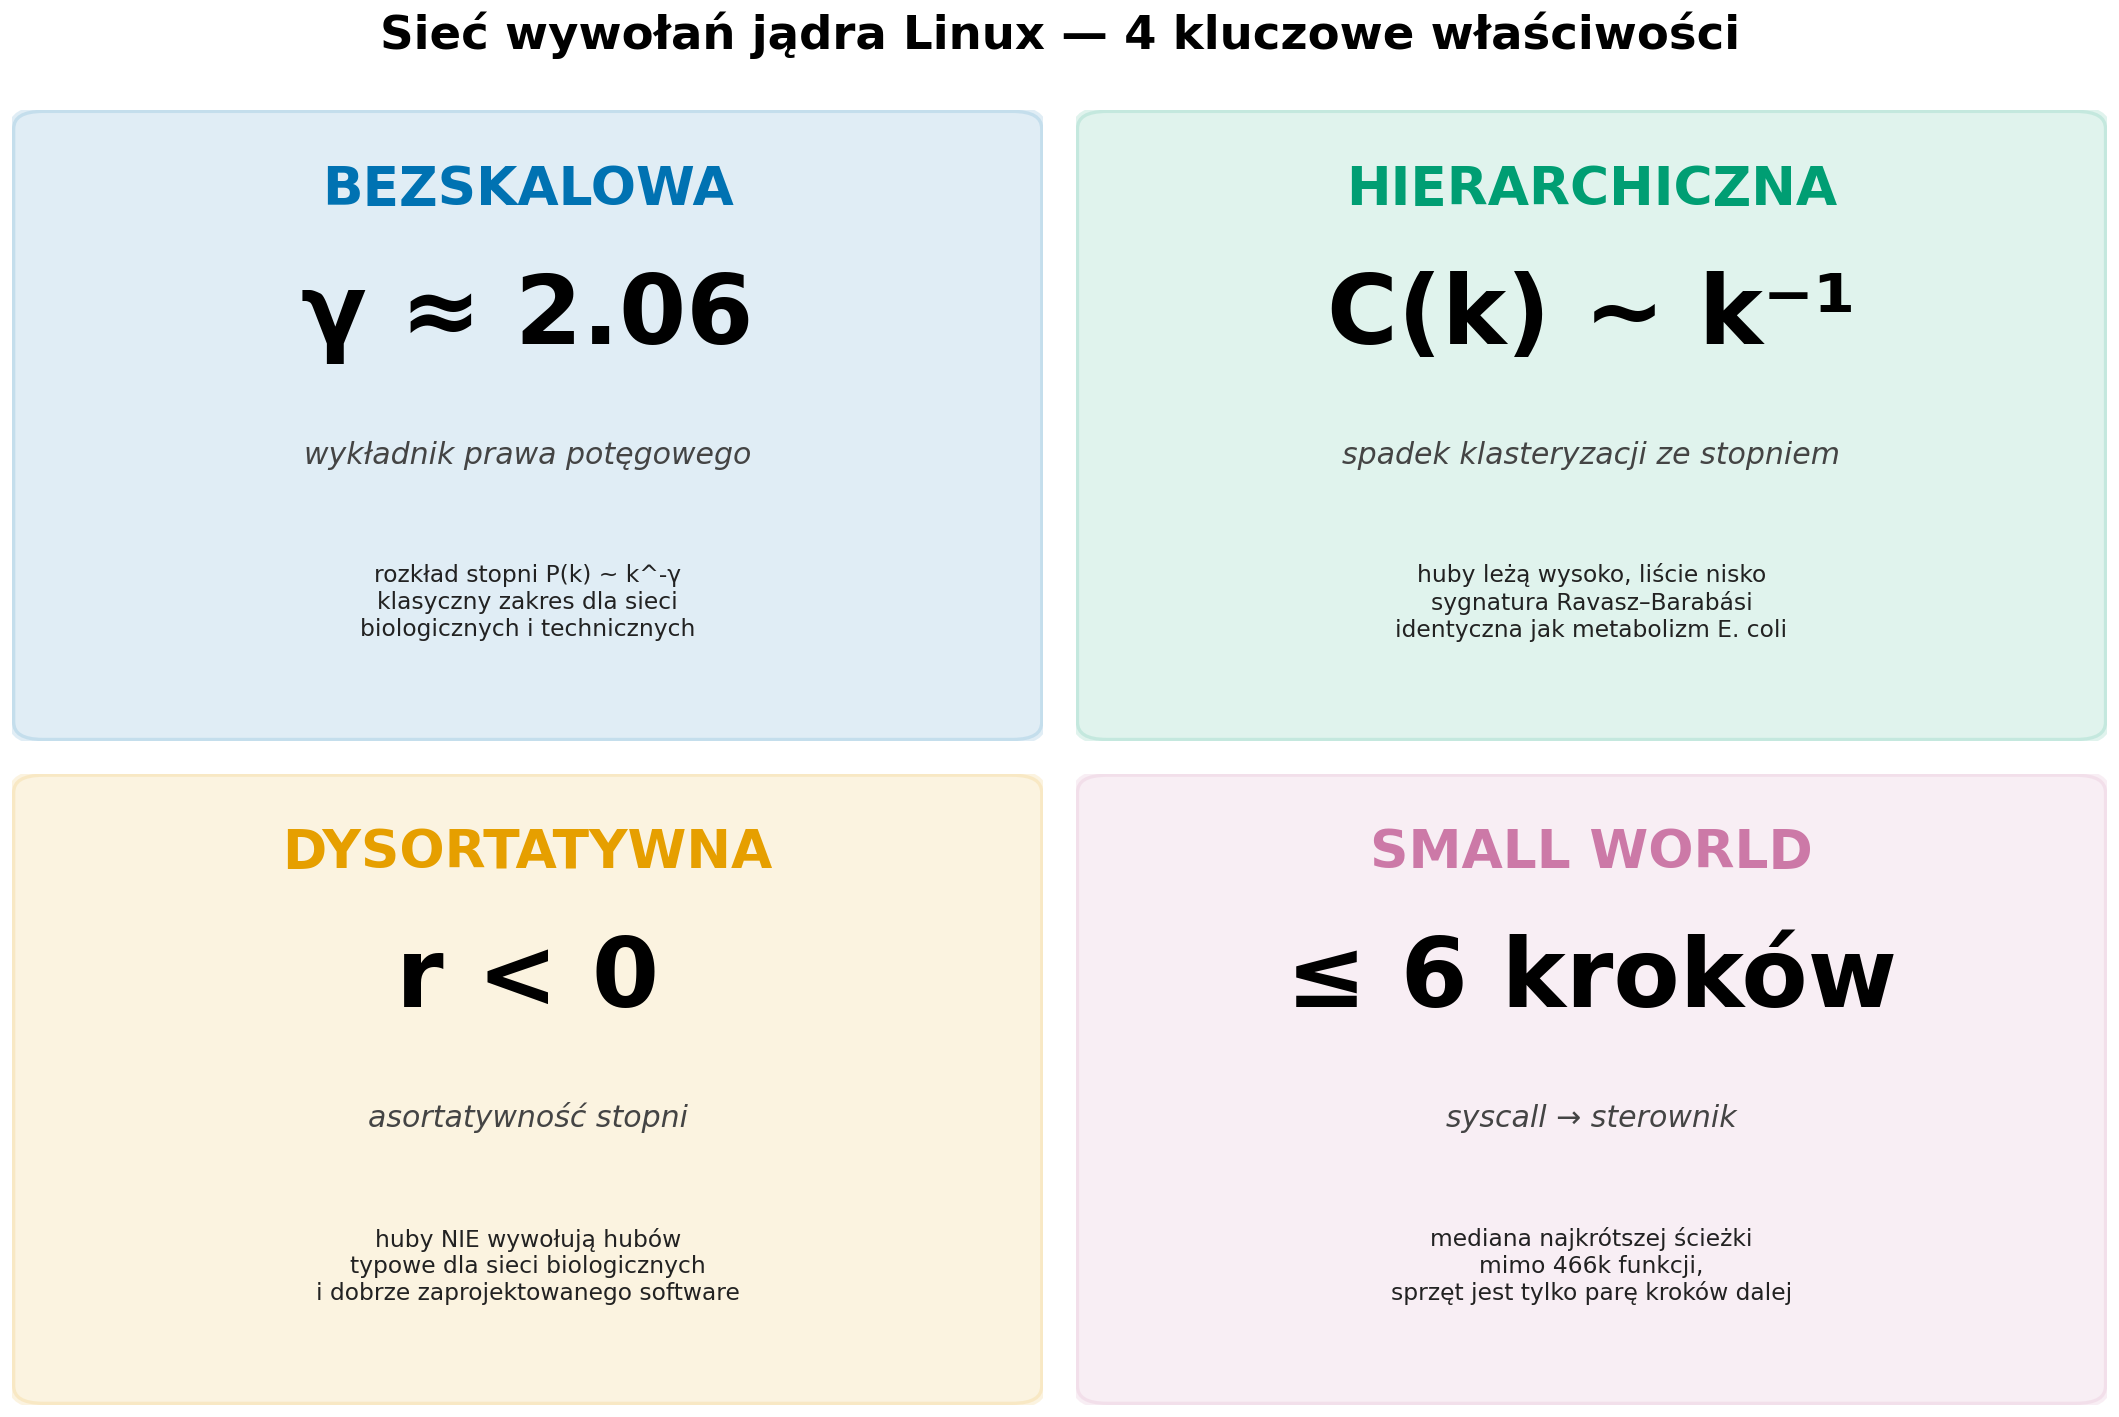

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

panels = [
    {
        "title":  "BEZSKALOWA",
        "value":  "γ ≈ 2.06",
        "subtitle": "wykładnik prawa potęgowego",
        "desc":  "rozkład stopni P(k) ~ k^-γ\nklasyczny zakres dla sieci\nbiologicznych i technicznych",
        "color":  WONG[0],
    },
    {
        "title":  "HIERARCHICZNA",
        "value":  "C(k) ~ k⁻¹",
        "subtitle": "spadek klasteryzacji ze stopniem",
        "desc":  "huby leżą wysoko, liście nisko\nsygnatura Ravasz–Barabási\nidentyczna jak metabolizm E. coli",
        "color":  WONG[2],
    },
    {
        "title":  "DYSORTATYWNA",
        "value":  "r < 0",
        "subtitle": "asortatywność stopni",
        "desc":  "huby NIE wywołują hubów\ntypowe dla sieci biologicznych\ni dobrze zaprojektowanego software",
        "color":  WONG[1],
    },
    {
        "title":  "SMALL WORLD",
        "value":  "≤ 6 kroków",
        "subtitle": "syscall → sterownik",
        "desc":  "mediana najkrótszej ścieżki\nmimo 466k funkcji,\nsprzęt jest tylko parę kroków dalej",
        "color":  WONG[3],
    },
]

for ax, p in zip(axes.flat, panels):
    ax.set_xlim(0, 10); ax.set_ylim(0, 10)
    ax.axis("off")
    # Tło
    bg = mpatches.FancyBboxPatch((0.3, 0.3), 9.4, 9.4,
                                  boxstyle="round,pad=0.3",
                                  facecolor=p["color"], alpha=0.12,
                                  edgecolor=p["color"], linewidth=4)
    ax.add_patch(bg)
    # Title
    ax.text(5, 8.5, p["title"], fontsize=32, fontweight="bold",
            ha="center", color=p["color"])
    # Główna wartość
    ax.text(5, 6.3, p["value"], fontsize=58, fontweight="bold",
            ha="center", color="black")
    # Subtitle
    ax.text(5, 4.4, p["subtitle"], fontsize=18, ha="center",
            style="italic", color="#444")
    # Opis
    ax.text(5, 2.2, p["desc"], fontsize=14, ha="center", va="center",
            color="#222")

fig.suptitle("Sieć wywołań jądra Linux — 4 kluczowe właściwości",
             fontsize=28, fontweight="bold", y=0.99)
plt.tight_layout()
save_fig(fig, "05_key_findings")
plt.show()

## Figura 6 — Diagram przepływu (concept figure)

Pojęciowy obraz działania sieci, ręcznie rysowany w matplotlib.
Pokazuje: USER-SPACE → SYSCALL → VFS → DRIVER → HARDWARE.

  zapisano: 06_concept_diagram.png + 06_concept_diagram.pdf


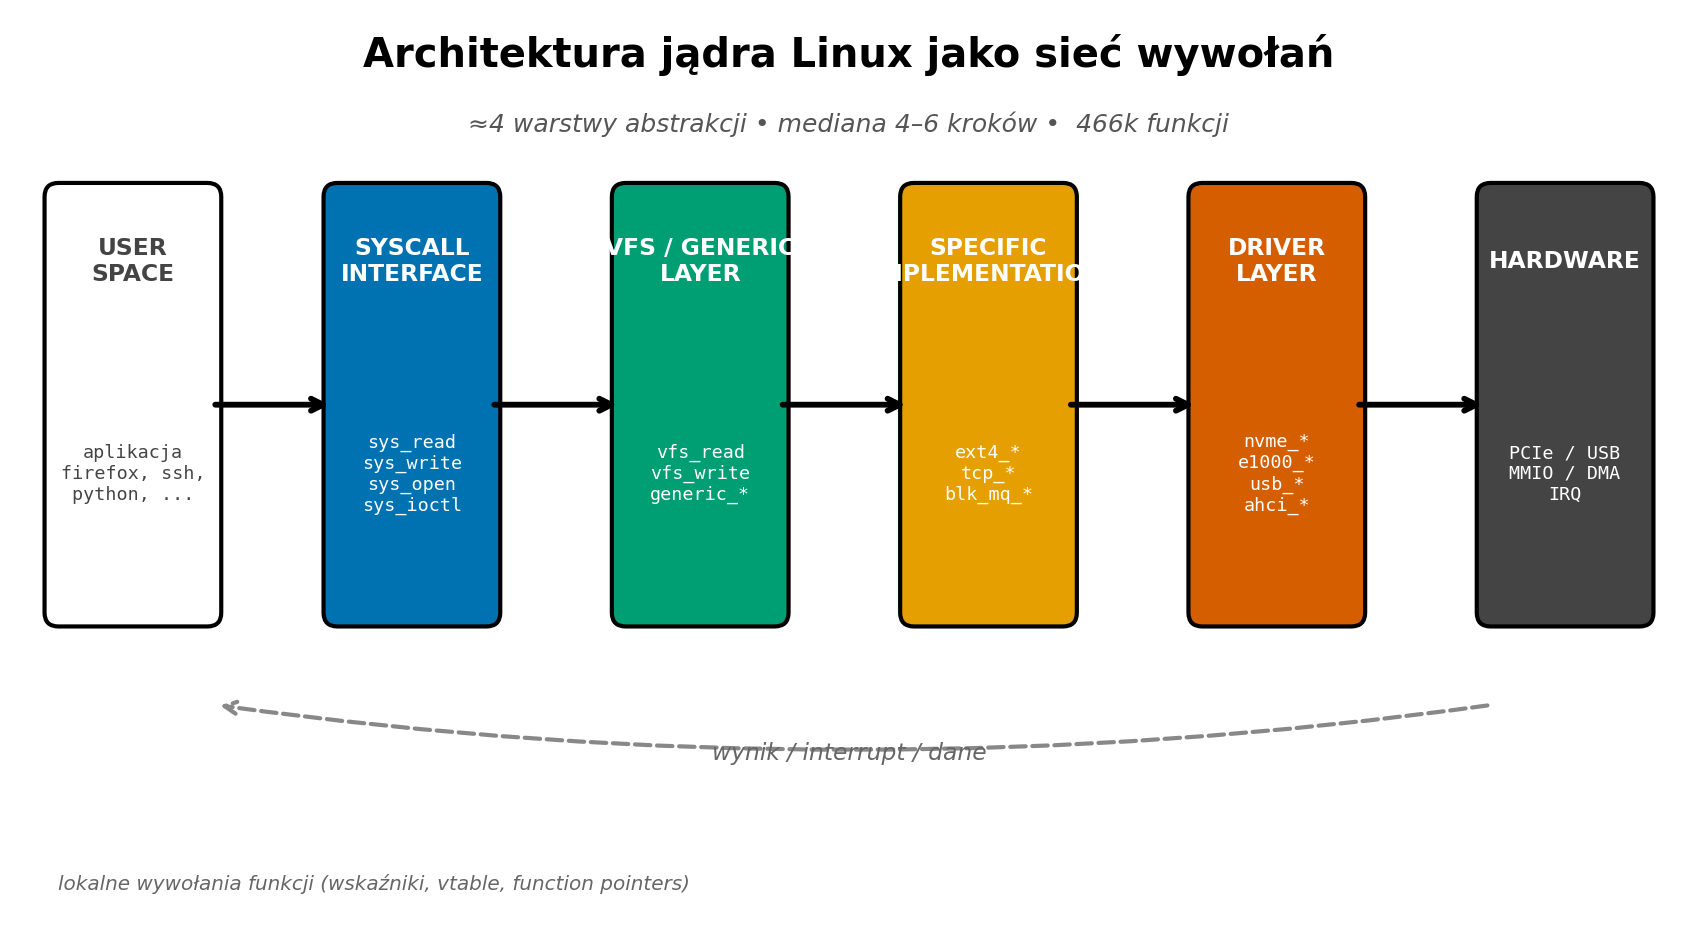

In [7]:
fig, ax = plt.subplots(figsize=(18, 10))
ax.set_xlim(0, 18); ax.set_ylim(0, 10)
ax.axis("off")

# Bloki warstw
blocks = [
    (0.5, "USER\nSPACE",       "aplikacja\nfirefox, ssh,\npython, ...", "#ffffff", "#444444"),
    (3.5, "SYSCALL\nINTERFACE", "sys_read\nsys_write\nsys_open\nsys_ioctl", WONG[0], "white"),
    (6.6, "VFS / GENERIC\nLAYER", "vfs_read\nvfs_write\ngeneric_*", WONG[2], "white"),
    (9.7, "SPECIFIC\nIMPLEMENTATION", "ext4_*\ntcp_*\nblk_mq_*", WONG[1], "white"),
    (12.8, "DRIVER\nLAYER",     "nvme_*\ne1000_*\nusb_*\nahci_*", WONG[6], "white"),
    (15.9, "HARDWARE",           "PCIe / USB\nMMIO / DMA\nIRQ", "#444444", "white"),
]

for x, name, content, fc, tc in blocks:
    box = mpatches.FancyBboxPatch((x, 3.5), 1.6, 4.5,
                                   boxstyle="round,pad=0.15",
                                   facecolor=fc, edgecolor="black", linewidth=2.5)
    ax.add_patch(box)
    ax.text(x + 0.8, 7.3, name, ha="center", va="center",
            fontsize=14, fontweight="bold", color=tc)
    ax.text(x + 0.8, 5.0, content, ha="center", va="center",
            fontsize=11, color=tc, family="monospace")

# Strzałki w prawo
for i in range(len(blocks) - 1):
    x0 = blocks[i][0] + 1.6
    x1 = blocks[i+1][0]
    ax.annotate("", xy=(x1 - 0.05, 5.75), xytext=(x0 + 0.05, 5.75),
                arrowprops=dict(arrowstyle="->", lw=3.5, color="black"))

# Strzałka powrotu (callback)
ax.annotate("", xy=(2.2, 2.5), xytext=(15.9, 2.5),
            arrowprops=dict(arrowstyle="->", lw=2.5, color="#888",
                            connectionstyle="arc3,rad=-0.07", linestyle="--"))
ax.text(9.0, 1.9, "wynik / interrupt / dane", ha="center", fontsize=14,
        style="italic", color="#666")

# Tytuł i metryki
ax.text(9, 9.4, "Architektura jądra Linux jako sieć wywołań",
        ha="center", fontsize=24, fontweight="bold")
ax.text(9, 8.7, "≈4 warstwy abstrakcji • mediana 4–6 kroków •  466k funkcji",
        ha="center", fontsize=15, style="italic", color="#555")

# Adnotacje - typy wywołań
ax.text(0.5, 0.5, "lokalne wywołania funkcji (wskaźniki, vtable, function pointers)",
        fontsize=12, color="#666", style="italic")

save_fig(fig, "06_concept_diagram")
plt.show()

## Eksport — co mamy w `../figures/poster/`

Każda figura jest dostępna jako PNG (300 DPI, do druku) i PDF (wektorowy, do skalowania).

In [8]:
from pathlib import Path

OUT = Path("../figures/poster")
files = sorted(OUT.glob("*.png")) + sorted(OUT.glob("*.pdf"))

print(f"Wygenerowane figury w {OUT.resolve()}:\n")
for f in files:
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<50s}  {size_kb:>8.1f} KB")

print("\n" + "="*60)
print("WSKAZÓWKI POSTEROWE")
print("="*60)
print("""
- Figure 1 (HERO) → użyj jako główny "eye-catcher" na środku/górze postera
- Figure 5 (key findings) → boczna kolumna lub dół, jako podsumowanie
- Figure 6 (concept) → pasek poziomy na górze postera, ilustruje "co i jak"
- Figury 2-4 → szczegółowe sekcje poszczególnych analiz

ROZMIAR DRUKU:
- 300 DPI × 16 cali = 4800 pikseli — wystarczy na figurę szerokości 40 cm na A0
- PDF jest wektorowy — nie traci jakości przy skalowaniu

PORADA:
W LaTeX/InDesign używaj wersji PDF; w PowerPoint/Affinity — PNG.
""")

Wygenerowane figury w /workspaces/linux-complex-networks/figures/poster:

  01_hero_powerlaw.png                                   470.6 KB
  02_subsystem_ecosystem.png                             736.0 KB
  03_network_at_glance.png                               784.6 KB
  04_hierarchy_signature.png                             333.5 KB
  05_key_findings.png                                    653.6 KB
  06_concept_diagram.png                                 351.0 KB
  01_hero_powerlaw.pdf                                    39.9 KB
  02_subsystem_ecosystem.pdf                              49.3 KB
  03_network_at_glance.pdf                               141.0 KB
  04_hierarchy_signature.pdf                              37.5 KB
  05_key_findings.pdf                                     46.4 KB
  06_concept_diagram.pdf                                  42.8 KB

WSKAZÓWKI POSTEROWE

- Figure 1 (HERO) → użyj jako główny "eye-catcher" na środku/górze postera
- Figure 5 (key findings) → boczna ko